# Machine Learning Benchmark: circRNA Feature Sweeps

This notebook systematically evaluates the predictive power of different circRNA feature sets (Raw, DE-filtered, GSEA-filtered) against clinical targets using the `polyssifier` library.

## Clinical Targets & Psychometric Scores

Here is a breakdown of the clinical scores available in the metadata and their standard thresholds for classification:

1. **Sex**: Categorical (`Male` vs `Female`).
2. **Age**: Continuous. We will binarize using a **median split** (Older vs Younger).
3. **Response**: Categorical (`Yes` vs `No`). Note: Not all samples have response data (only Post/During visits typically).
4. **GAD-7 (Generalized Anxiety Disorder 7-item scale)**
   - **What it is**: Measures severity of anxiety symptoms.
   - **Standard Cutoffs**: 0-4 (Minimal), 5-9 (Mild), 10-14 (Moderate), 15-21 (Severe).
   - **Threshold Used**: `>= 10` is the widely accepted clinical cutoff for identifying clinically significant anxiety.
5. **IDS-C (Inventory of Depressive Symptomatology - Clinician-Rated)**
   - **What it is**: Assesses the severity of depressive symptoms.
   - **Standard Cutoffs**: $\le 11$ (Normal), 12-23 (Mild), 24-36 (Moderate), 37-46 (Severe), $\ge 47$ (Very Severe).
   - **Threshold Used**: `>= 24` to distinguish Moderate-to-Severe depression from None/Mild.
6. **YMRS (Young Mania Rating Scale)**
   - **What it is**: Assesses severity of manic symptoms.
   - **Threshold Used**: `<= 12` (Remission) vs `> 12` (Active symptoms).
7. **SHAPSC (Snaith-Hamilton Pleasure Scale) & TEPS (Temporal Experience of Pleasure Scale)**
   - **What they are**: Measures of anhedonia and pleasure.
   - **Threshold Used**: Because these are scored continuously over a wide range in this cohort, we will use a **median split** to classify High vs. Low.


In [12]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from polyssifier import poly
from data_loaders import load_raw_filtered_circRNAs, load_de_filtered_circRNAs, load_gsea_filtered_circRNAs


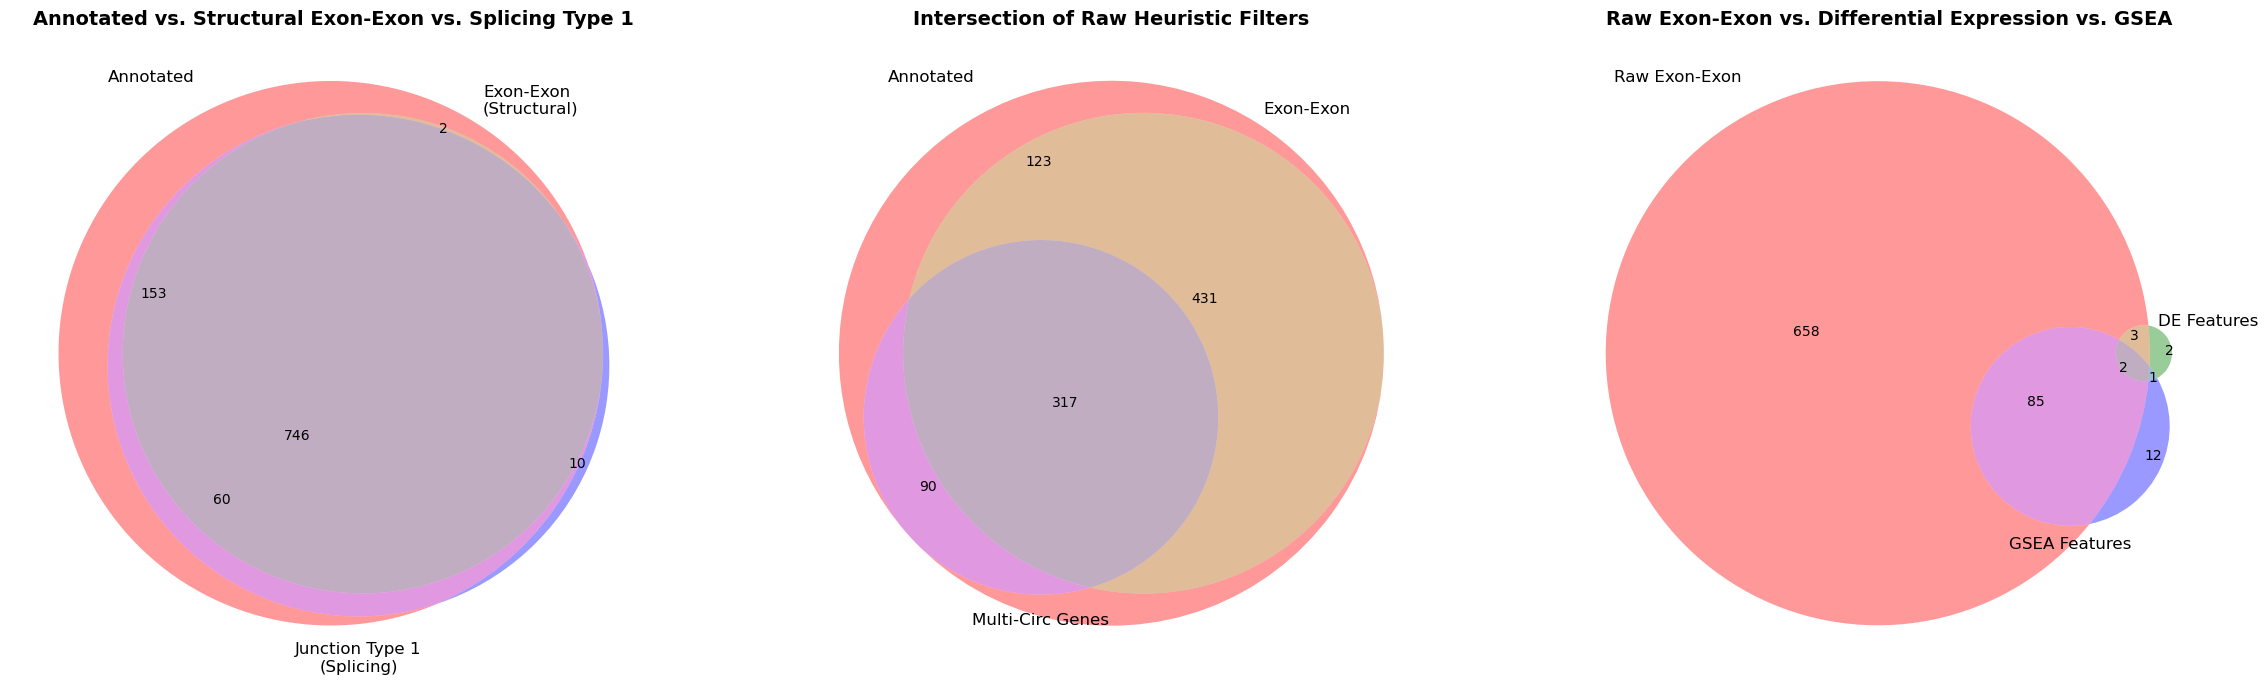

In [13]:
from docutils.nodes import Structural
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from data_loaders import load_raw_filtered_circRNAs, load_de_filtered_circRNAs, load_gsea_filtered_circRNAs
import warnings
warnings.filterwarnings('ignore')

# 1. Load the target IDs for all sets instantly (apply_filter=False)
_, _, t_annot = load_raw_filtered_circRNAs('annotated_only', apply_filter=False)
_, _, t_exon = load_raw_filtered_circRNAs('exon_exon_only', apply_filter=False)
_, _, t_junc1 = load_raw_filtered_circRNAs('junction_type_1', apply_filter=False)
_, _, t_multi = load_raw_filtered_circRNAs('multi_circ_genes_only', apply_filter=False)
_, _, t_de = load_de_filtered_circRNAs(analyses=list(range(8)), apply_filter=False)
_, _, t_gsea = load_gsea_filtered_circRNAs(analyses=list(range(8)), apply_filter=False)

sets = {
    'Annotated': set(t_annot),
    'ExonExon': set(t_exon),
    'JunctionType1': set(t_junc1),
    'MultiCirc': set(t_multi),
    'DE_Features': set(t_de),
    'GSEA_Features': set(t_gsea)
}

# Note: upsetplot is currently broken on Pandas 3.0+ (which you are using) 
# due to strict Copy-on-Write enforcement breaking their internal color shading.
# So we will use 3 targeted Venn Diagrams instead!

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Venn A: Structural vs Splicing Mechanisms
venn3([sets['Annotated'], sets['ExonExon'], sets['JunctionType1']], 
      set_labels=('Annotated', 'Exon-Exon\n(Structural)', 'Junction Type 1\n(Splicing)'), ax=axes[0])
axes[0].set_title('Annotated vs. Structural Exon-Exon vs. Splicing Type 1', fontsize=14, fontweight='bold')

# Venn B: How do the 3 raw heuristic filters relate?
venn3([sets['Annotated'], sets['ExonExon'], sets['MultiCirc']], 
      set_labels=('Annotated', 'Exon-Exon', 'Multi-Circ Genes'), ax=axes[1])
axes[1].set_title('Intersection of Raw Heuristic Filters', fontsize=14, fontweight='bold')

# Venn C: How do DE and GSEA relate to the cleanest raw subset (ExonExon)?
venn3([sets['ExonExon'], sets['DE_Features'], sets['GSEA_Features']], 
      set_labels=('Raw Exon-Exon', 'DE Features', 'GSEA Features'), ax=axes[2])
axes[2].set_title('Raw Exon-Exon vs. Differential Expression vs. GSEA', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [14]:
def prepare_ml_data(counts_df, metadata_df, target_col, threshold=None, threshold_type='value', positive_class=None):
    '''
    Transposes counts, aligns with metadata, handles missing values, and binarizes the target.
    
    Parameters:
    - counts_df: Features x Samples dataframe.
    - metadata_df: Clinical metadata dataframe.
    - target_col: Column name in metadata to predict (e.g., 'Sex', 'GAD-7').
    - threshold: Value to split on (if continuous). If None and threshold_type is 'median', uses the median.
    - threshold_type: 'value' (e.g. >= threshold) or 'median' (>= median).
    - positive_class: If categorical, which value to treat as positive (1). Optional.
    '''
    # 1. Ensure metadata has the target column
    if target_col not in metadata_df.columns:
        raise ValueError(f"Target column '{target_col}' not found in metadata.")
        
    # 2. Extract valid samples that have a label for this target
    valid_meta = metadata_df.dropna(subset=[target_col]).copy()
    
    # Binarize if requested
    if threshold_type == 'median':
        thresh_val = valid_meta[target_col].median()
        print(f"Binarizing {target_col} by median (>= {thresh_val:.2f})")
        valid_meta['label'] = (valid_meta[target_col] >= thresh_val).astype(int)
    elif threshold is not None:
        print(f"Binarizing {target_col} by fixed threshold (>= {threshold})")
        valid_meta['label'] = (valid_meta[target_col] >= threshold).astype(int)
    elif positive_class is not None:
        valid_meta['label'] = (valid_meta[target_col] == positive_class).astype(int)
    else:
        # If it's already categorical like Male/Female but we just want an int mapping
        cats = valid_meta[target_col].unique()
        if len(cats) == 2:
            print(f"Mapping {cats[0]} -> 0, {cats[1]} -> 1")
            valid_meta['label'] = (valid_meta[target_col] == cats[1]).astype(int)
        else:
            # Multi-class
            valid_meta['label'] = valid_meta[target_col].astype('category').cat.codes
            
    # 3. Transpose counts (Samples as rows, Features as columns)
    sample_cols = [c for c in counts_df.columns if c.startswith('M87')]
    X_df = counts_df.set_index('circRNA_id')[sample_cols].T
    
    # 4. Align X and y
    valid_meta = valid_meta[valid_meta['map_id'].isin(X_df.index)]
    X_aligned = X_df.loc[valid_meta['map_id']]
    y_aligned = valid_meta['label'].values
    
    # Log sizes
    print(f"\n--- Data Preparation for Target: {target_col} ---")
    print(f"Initial valid samples with labels: {len(valid_meta)}")
    print(f"Samples perfectly aligned with count matrix: {len(X_aligned)}")
    
    # Log class balance
    unique, counts = np.unique(y_aligned, return_counts=True)
    balance = dict(zip(unique, counts))
    print(f"Class balance: {balance}\n")
    
    return X_aligned.values, y_aligned


In [15]:
def run_feature_sweep(target_col, threshold=None, threshold_type='value', positive_class=None):
    '''
    Runs the polyssifier benchmark across all major feature extraction methods.
    '''
    print(f"========== STARTING SWEEP FOR: {target_col} ==========\n")
    
    # Define our feature configurations
    configs = {
        'Raw_Annotated': lambda: load_raw_filtered_circRNAs('annotated_only', apply_filter=True),
        'Raw_ExonExon': lambda: load_raw_filtered_circRNAs('exon_exon_only', apply_filter=True),
        'Raw_JunctionType1': lambda: load_raw_filtered_circRNAs('junction_type_1', apply_filter=True),
        'Raw_MultiCircGenes': lambda: load_raw_filtered_circRNAs('multi_circ_genes_only', apply_filter=True),
        'DE_All_Analyses': lambda: load_de_filtered_circRNAs(analyses=list(range(8)), apply_filter=True),
        'GSEA_All_Analyses': lambda: load_gsea_filtered_circRNAs(analyses=list(range(8)), apply_filter=True)
    }
    
    results = {}
    
    for name, loader_func in configs.items():
        print(f"\n>>> Testing Feature Set: {name}")
        counts, meta, targets = loader_func()
        print(f"Number of features loaded: {len(targets)}")
        
        try:
            X, y = prepare_ml_data(counts, meta, target_col, threshold, threshold_type, positive_class)
            
            if len(y) < 10:
                print("Too few samples to run reliable CV. Skipping.")
                continue
                
            # Run polyssifier
            poly_results = poly(X, y, n_folds=5, scoring='auc', feature_selection=False, verbose=False)
            
            scores_df = poly_results.scores
            
            # Extract all test scores across the 5 folds
            test_scores = scores_df.xs('test', level=1, axis=1)
            mean_scores = test_scores.mean()
            
            print("Mean AUC across 5-folds:")
            print(mean_scores.sort_values(ascending=False).head(3))
            
            # Calculate class balance
            unique, counts_arr = np.unique(y, return_counts=True)
            balance_dict = dict(zip(unique.astype(str), counts_arr.astype(int)))
            
            # Return a rich dictionary instead of just mean_scores
            results[name] = {
                'all_scores': test_scores,
                'mean_scores': mean_scores,
                'n_features': len(targets),
                'n_samples': len(y),
                'balance': balance_dict
            }
        except Exception as e:
            print(f"Failed: {e}")
            
    return results


## 1. Predicting Biological Sex

In [16]:
res_sex = run_feature_sweep('Sex')

========== STARTING SWEEP FOR: Sex ==========


>>> Testing Feature Set: Raw_Annotated
Number of features loaded: 961
Mapping Male -> 0, Female -> 1

--- Data Preparation for Target: Sex ---
Initial valid samples with labels: 24
Samples perfectly aligned with count matrix: 24
Class balance: {np.int64(0): np.int64(15), np.int64(1): np.int64(9)}

predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (4,)
Mean AUC across 5-folds:
Decision Tree        0.633333
Nearest Neighbors         0.6
Random Forest             0.6
dtype: object

>>> Testing Feature Set: Raw_ExonExon
Number of features loaded: 748
Mapping Male -> 0, Female -> 1

--- Data Preparation for Target: Sex ---
Initial valid samples with labels: 24
Samples perfectly aligned with count matrix: 24
Class balance: {np.int64(0): np.int64(15), np.int64(1): np.int64(9)}

predict proba return shape (5,)
predict proba return shape (5,)
p

## 2. Predicting Age (Median Split)

In [17]:
res_age = run_feature_sweep('Age', threshold_type='median')

========== STARTING SWEEP FOR: Age ==========


>>> Testing Feature Set: Raw_Annotated
Number of features loaded: 961
Binarizing Age by median (>= 32.50)

--- Data Preparation for Target: Age ---
Initial valid samples with labels: 24
Samples perfectly aligned with count matrix: 24
Class balance: {np.int64(0): np.int64(12), np.int64(1): np.int64(12)}

predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (4,)
Mean AUC across 5-folds:
Random Forest            0.85
Nearest Neighbors         0.8
Voting               0.766667
dtype: object

>>> Testing Feature Set: Raw_ExonExon
Number of features loaded: 748
Binarizing Age by median (>= 32.50)

--- Data Preparation for Target: Age ---
Initial valid samples with labels: 24
Samples perfectly aligned with count matrix: 24
Class balance: {np.int64(0): np.int64(12), np.int64(1): np.int64(12)}

predict proba return shape (5,)
predict proba return 

## 3. Predicting Treatment Response

In [18]:
res_resp = run_feature_sweep('Response', positive_class='Yes')

========== STARTING SWEEP FOR: Response ==========


>>> Testing Feature Set: Raw_Annotated
Number of features loaded: 961

--- Data Preparation for Target: Response ---
Initial valid samples with labels: 15
Samples perfectly aligned with count matrix: 15
Class balance: {np.int64(0): np.int64(12), np.int64(1): np.int64(3)}

predict proba return shape (3,)
predict proba return shape (3,)
predict proba return shape (3,)
predict proba return shape (3,)
predict proba return shape (3,)
Mean AUC across 5-folds:
Logistic Regression     0.8
Nearest Neighbors      0.75
Random Forest           0.7
dtype: object

>>> Testing Feature Set: Raw_ExonExon
Number of features loaded: 748

--- Data Preparation for Target: Response ---
Initial valid samples with labels: 15
Samples perfectly aligned with count matrix: 15
Class balance: {np.int64(0): np.int64(12), np.int64(1): np.int64(3)}

predict proba return shape (3,)
predict proba return shape (3,)
predict proba return shape (3,)
predict proba return s

## 4. Predicting Anxiety (GAD-7 >= 10)

In [19]:
res_gad7 = run_feature_sweep('GAD-7', threshold=10, threshold_type='value')

========== STARTING SWEEP FOR: GAD-7 ==========


>>> Testing Feature Set: Raw_Annotated
Number of features loaded: 961
Binarizing GAD-7 by fixed threshold (>= 10)

--- Data Preparation for Target: GAD-7 ---
Initial valid samples with labels: 24
Samples perfectly aligned with count matrix: 24
Class balance: {np.int64(0): np.int64(14), np.int64(1): np.int64(10)}

predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (4,)
Mean AUC across 5-folds:
Random Forest          0.966667
Logistic Regression    0.966667
Nearest Neighbors          0.95
dtype: object

>>> Testing Feature Set: Raw_ExonExon
Number of features loaded: 748
Binarizing GAD-7 by fixed threshold (>= 10)

--- Data Preparation for Target: GAD-7 ---
Initial valid samples with labels: 24
Samples perfectly aligned with count matrix: 24
Class balance: {np.int64(0): np.int64(14), np.int64(1): np.int64(10)}

predict proba return shap

## 5. Predicting Depression Severity (IDS-C >= 24)

In [20]:
res_idsc = run_feature_sweep('IDS-C', threshold=24, threshold_type='value')

========== STARTING SWEEP FOR: IDS-C ==========


>>> Testing Feature Set: Raw_Annotated
Number of features loaded: 961
Binarizing IDS-C by fixed threshold (>= 24)

--- Data Preparation for Target: IDS-C ---
Initial valid samples with labels: 24
Samples perfectly aligned with count matrix: 24
Class balance: {np.int64(0): np.int64(7), np.int64(1): np.int64(17)}

predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (4,)
Mean AUC across 5-folds:
Multilayer Perceptron    0.933333
Nearest Neighbors            0.65
Random Forest               0.625
dtype: object

>>> Testing Feature Set: Raw_ExonExon
Number of features loaded: 748
Binarizing IDS-C by fixed threshold (>= 24)

--- Data Preparation for Target: IDS-C ---
Initial valid samples with labels: 24
Samples perfectly aligned with count matrix: 24
Class balance: {np.int64(0): np.int64(7), np.int64(1): np.int64(17)}

predict proba return 

## 6. Predicting Manic Symptoms (YMRS > 12)

In [21]:
res_ymrs = run_feature_sweep('YMRS', threshold=13, threshold_type='value')

========== STARTING SWEEP FOR: YMRS ==========


>>> Testing Feature Set: Raw_Annotated
Number of features loaded: 961
Binarizing YMRS by fixed threshold (>= 13)

--- Data Preparation for Target: YMRS ---
Initial valid samples with labels: 24
Samples perfectly aligned with count matrix: 24
Class balance: {np.int64(0): np.int64(21), np.int64(1): np.int64(3)}

predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (4,)
Mean AUC across 5-folds:
Decision Tree            0.777778
SVM                          0.75
Multilayer Perceptron    0.721429
dtype: object

>>> Testing Feature Set: Raw_ExonExon
Number of features loaded: 748
Binarizing YMRS by fixed threshold (>= 13)

--- Data Preparation for Target: YMRS ---
Initial valid samples with labels: 24
Samples perfectly aligned with count matrix: 24
Class balance: {np.int64(0): np.int64(21), np.int64(1): np.int64(3)}

predict proba return shape

## 7. Predicting Anhedonia (SHAPSC Median Split)

In [22]:
res_shapsc = run_feature_sweep('SHAPSC', threshold_type='median')

========== STARTING SWEEP FOR: SHAPSC ==========


>>> Testing Feature Set: Raw_Annotated
Number of features loaded: 961
Binarizing SHAPSC by median (>= 39.50)

--- Data Preparation for Target: SHAPSC ---
Initial valid samples with labels: 24
Samples perfectly aligned with count matrix: 24
Class balance: {np.int64(0): np.int64(12), np.int64(1): np.int64(12)}

predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (5,)
predict proba return shape (4,)
Mean AUC across 5-folds:
SVM                   0.7
Linear SVM            0.6
Decision Tree    0.516667
dtype: object

>>> Testing Feature Set: Raw_ExonExon
Number of features loaded: 748
Binarizing SHAPSC by median (>= 39.50)

--- Data Preparation for Target: SHAPSC ---
Initial valid samples with labels: 24
Samples perfectly aligned with count matrix: 24
Class balance: {np.int64(0): np.int64(12), np.int64(1): np.int64(12)}

predict proba return shape (5,)
predict proba retu

## 8. Aggregate Results
Merge all sweeps into a single comparative DataFrame.

In [23]:
import pandas as pd
import numpy as np

all_results = {
    'Sex': res_sex,
    'Age': res_age,
    'Response': res_resp,
    'GAD-7': res_gad7,
    'IDS-C': res_idsc,
    'YMRS': res_ymrs,
    'SHAPSC': res_shapsc
}

rows = []
for task_name, task_res in all_results.items():
    # Skip if task failed or has no results
    if not task_res: continue
    
    for feature_set, info in task_res.items():
        mean_scores = info['mean_scores']
        
        top_clf = mean_scores.idxmax()
        top_score = mean_scores.max()
        
        n_samp = info['n_samples']
        n_feat = info['n_features']
        bal = info['balance']
        
        # Format balance cleanly (e.g., "15:9")
        if len(bal) == 2:
            bal_str = ":".join(map(str, bal.values()))
        else:
            bal_str = str(bal)
            
        # Decorate the names with metadata for the Pivot Table
        display_task = f"{task_name} (N={n_samp} | {bal_str})"
        display_feat = f"{feature_set} (n={n_feat})"
    
        
        rows.append({
            'Task': display_task,
            'Feature_Set': display_feat,
            'Top_Classifier': top_clf,
            'Mean_AUC': top_score,
            'CV_Folds_AUC': info['all_scores'][top_clf].astype(float).round(3).tolist()
        })

master_df = pd.DataFrame(rows)
summary_table = master_df.pivot(index='Task', columns='Feature_Set', values='Mean_AUC')
summary_table.loc['Mean_Across_Tasks'] = summary_table.mean(axis=0)

print("=== BEST Mean AUC per Task and Feature Set ===")
display(summary_table.round(3))

print("\n\n=== Detailed Information (Including All CV Folds) ===")
display(master_df)


=== BEST Mean AUC per Task and Feature Set ===


Feature_Set,DE_All_Analyses (n=8),GSEA_All_Analyses (n=100),Raw_Annotated (n=961),Raw_ExonExon (n=748),Raw_JunctionType1 (n=816),Raw_MultiCircGenes (n=407)
Task,,,,,,
Age (N=24 | 12:12),0.742,0.817,0.850,0.850,0.950,0.833
GAD-7 (N=24 | 14:10),0.967,1.000,0.967,0.967,1.000,0.967
IDS-C (N=24 | 7:17),0.717,0.792,0.933,0.733,0.667,0.700
Response (N=15 | 12:3),0.800,1.000,0.800,0.800,0.800,0.960
SHAPSC (N=24 | 12:12),0.700,0.617,0.700,0.733,0.633,0.700
Sex (N=24 | 15:9),0.600,0.783,0.633,0.567,0.717,0.867
YMRS (N=24 | 21:3),0.875,0.846,0.778,0.800,0.800,0.900
Mean_Across_Tasks,0.771,0.836,0.809,0.779,0.795,0.847




=== Detailed Information (Including All CV Folds) ===


,Task,Feature_Set,Top_Classifier,Mean_AUC,CV_Folds_AUC
0,Sex (N=24 | 15:9),Raw_Annotated (n=961),Decision Tree,0.633333,"[0.75, 1.0, 0.583, 0.5, 0.333]"
1,Sex (N=24 | 15:9),Raw_ExonExon (n=748),Nearest Neighbors,0.566667,"[0.417, 0.667, 0.667, 0.583, 0.5]"
2,Sex (N=24 | 15:9),Raw_JunctionType1 (n=816),Random Forest,0.716667,"[0.667, 0.917, 0.833, 0.5, 0.667]"
3,Sex (N=24 | 15:9),Raw_MultiCircGenes (n=407),Logistic Regression,0.866667,"[0.5, 1.0, 1.0, 0.833, 1.0]"
4,Sex (N=24 | 15:9),DE_All_Analyses (n=8),Random Forest,0.600000,"[0.25, 0.833, 0.667, 0.583, 0.667]"
5,Sex (N=24 | 15:9),GSEA_All_Analyses (n=100),Random Forest,0.783333,"[0.667, 0.667, 1.0, 0.583, 1.0]"
6,Age (N=24 | 12:12),Raw_Annotated (n=961),Random Forest,0.850000,"[0.75, 0.917, 0.583, 1.0, 1.0]"
7,Age (N=24 | 12:12),Raw_ExonExon (n=748),Random Forest,0.850000,"[0.667, 1.0, 0.917, 0.667, 1.0]"
8,Age (N=24 | 12:12),Raw_JunctionType1 (n=816),Random Forest,0.950000,"[0.917, 1.0, 0.833, 1.0, 1.0]"
9,Age (N=24 | 12:12),Raw_MultiCircGenes (n=407),Nearest Neighbors,0.833333,"[0.75, 1.0, 0.667, 1.0, 0.75]"


In [24]:
# Calculate the mean across all tasks (rows) for each feature set (column)
summary_table.loc['Mean_Across_Tasks'] = summary_table.mean(axis=0)

print("=== BEST Mean AUC per Task and Feature Set ===")
display(summary_table.round(3))


=== BEST Mean AUC per Task and Feature Set ===


Feature_Set,DE_All_Analyses (n=8),GSEA_All_Analyses (n=100),Raw_Annotated (n=961),Raw_ExonExon (n=748),Raw_JunctionType1 (n=816),Raw_MultiCircGenes (n=407)
Task,,,,,,
Age (N=24 | 12:12),0.742,0.817,0.850,0.850,0.950,0.833
GAD-7 (N=24 | 14:10),0.967,1.000,0.967,0.967,1.000,0.967
IDS-C (N=24 | 7:17),0.717,0.792,0.933,0.733,0.667,0.700
Response (N=15 | 12:3),0.800,1.000,0.800,0.800,0.800,0.960
SHAPSC (N=24 | 12:12),0.700,0.617,0.700,0.733,0.633,0.700
Sex (N=24 | 15:9),0.600,0.783,0.633,0.567,0.717,0.867
YMRS (N=24 | 21:3),0.875,0.846,0.778,0.800,0.800,0.900
Mean_Across_Tasks,0.771,0.836,0.809,0.779,0.795,0.847
